<a href="https://colab.research.google.com/github/jlanjos59/Areas_Disponiveis-semPontal/blob/main/Dash_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

filepath = '/content/drive/MyDrive/RegAmb-dasch-01.xlsx'
xls = pd.ExcelFile(filepath)
print("Sheet names:", xls.sheet_names)

for sheet in xls.sheet_names:
    df = pd.read_excel(filepath, sheet_name=sheet)
    print(f"\n--- Sheet: {sheet} ---")
    print(df.info())
    print(df.head(10))

Sheet names: ['passivo_dissolvido']

--- Sheet: passivo_dissolvido ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   assentamen  105 non-null    object 
 1   municipio   105 non-null    object 
 2   regional    105 non-null    object 
 3   gtc         105 non-null    object 
 4   Passivo-ha  105 non-null    float64
dtypes: float64(1), object(4)
memory usage: 4.2+ KB
None
                   assentamen                municipio  \
0             Santo Antônio 2     Presidente Bernardes   
1                     Guarani                Guatapará   
2  Santa Terezinha da Alcídia          Teodoro Sampaio   
3                  São Camilo     Presidente Venceslau   
4                Primavera II     Presidente Venceslau   
5             Washington Luiz  Mirante do Paranapanema   
6                   Fusquinha          Teodoro Sampaio   
7                

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/drive/MyDrive/RegAmb-dasch-01.xlsx', sheet_name='passivo_dissolvido')

print("Summary statistics of Passivo-ha:")
print(df['Passivo-ha'].describe())

print("\nTotal Passivo-ha:", df['Passivo-ha'].sum())
print("Total Assentamentos:", df['assentamen'].nunique())
print("Total Municipios:", df['municipio'].nunique())
print("Total Regionais:", df['regional'].nunique())
print("Total GTCs:", df['gtc'].nunique())

print("\nBy Regional:")
reg = df.groupby('regional')['Passivo-ha'].agg(['count', 'sum', 'mean', 'median', 'max']).sort_values(by='sum', ascending=False)
print(reg)

print("\nTop 10 Municipios by Passivo-ha:")
mun = df.groupby('municipio')['Passivo-ha'].agg(['count', 'sum']).sort_values(by='sum', ascending=False).head(10)
print(mun)

print("\nTop 10 Assentamentos by Passivo-ha:")
top_ass = df.sort_values(by='Passivo-ha', ascending=False).head(10)
print(top_ass[['assentamen', 'municipio', 'regional', 'Passivo-ha']])

Summary statistics of Passivo-ha:
count    105.000000
mean      24.924095
std       55.468627
min        0.110000
25%        1.460000
50%        4.720000
75%       18.320000
max      355.140000
Name: Passivo-ha, dtype: float64

Total Passivo-ha: 2617.03
Total Assentamentos: 105
Total Municipios: 31
Total Regionais: 4
Total GTCs: 13

By Regional:
                                count      sum       mean  median     max
regional                                                                 
Oeste (Pontal do Paranapanema)     80  2484.34  31.054250   5.885  355.14
Norte                              13    86.18   6.629231   4.310   24.56
Leste (Mogiana)                     9    37.94   4.215556   2.280   18.32
Sudoeste                            3     8.57   2.856667   0.660    7.25

Top 10 Municipios by Passivo-ha:
                            count     sum
municipio                                
Mirante do Paranapanema        28  719.18
Teodoro Sampaio                14  636.11
Presid

In [6]:
gtc_df = df.groupby(['regional', 'gtc'])['Passivo-ha'].agg(['count', 'sum', 'mean']).reset_index()
print(gtc_df.sort_values(by='sum', ascending=False))

                          regional                         gtc  count     sum  \
5   Oeste (Pontal do Paranapanema)     Mirante do Paranapanema     27  696.94   
10  Oeste (Pontal do Paranapanema)             Teodoro Sampaio     16  667.64   
8   Oeste (Pontal do Paranapanema)        Presidente Venceslau     14  489.85   
3   Oeste (Pontal do Paranapanema)  Euclides da Cunha Paulista      9  375.45   
4   Oeste (Pontal do Paranapanema)             Marabá Paulista      6  222.98   
1                            Norte                  Araraquara      8   56.71   
0                  Leste (Mogiana)                      Araras      9   37.94   
2                            Norte                   Bebedouro      5   29.47   
6   Oeste (Pontal do Paranapanema)        Presidente Bernardes      4   19.78   
9   Oeste (Pontal do Paranapanema)                      Rosana      3   11.19   
11                        Sudoeste                     Itapeva      1    7.25   
12                        Su

/tmp/ipykernel_1562/3611154642.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Passivo-ha', y='assentamen', data=top_ass, palette='Reds_r', ax=ax3)
/tmp/ipykernel_1562/3611154642.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='municipio', y='Passivo-ha', data=top_mun, palette='Blues_r', ax=ax4)
/tmp/ipykernel_1562/3611154642.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Passivo-ha', y='gtc', data=top_gtc, palette='Viridis_r', ax=ax5)


ValueError: 'Viridis_r' is not a valid palette name

/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


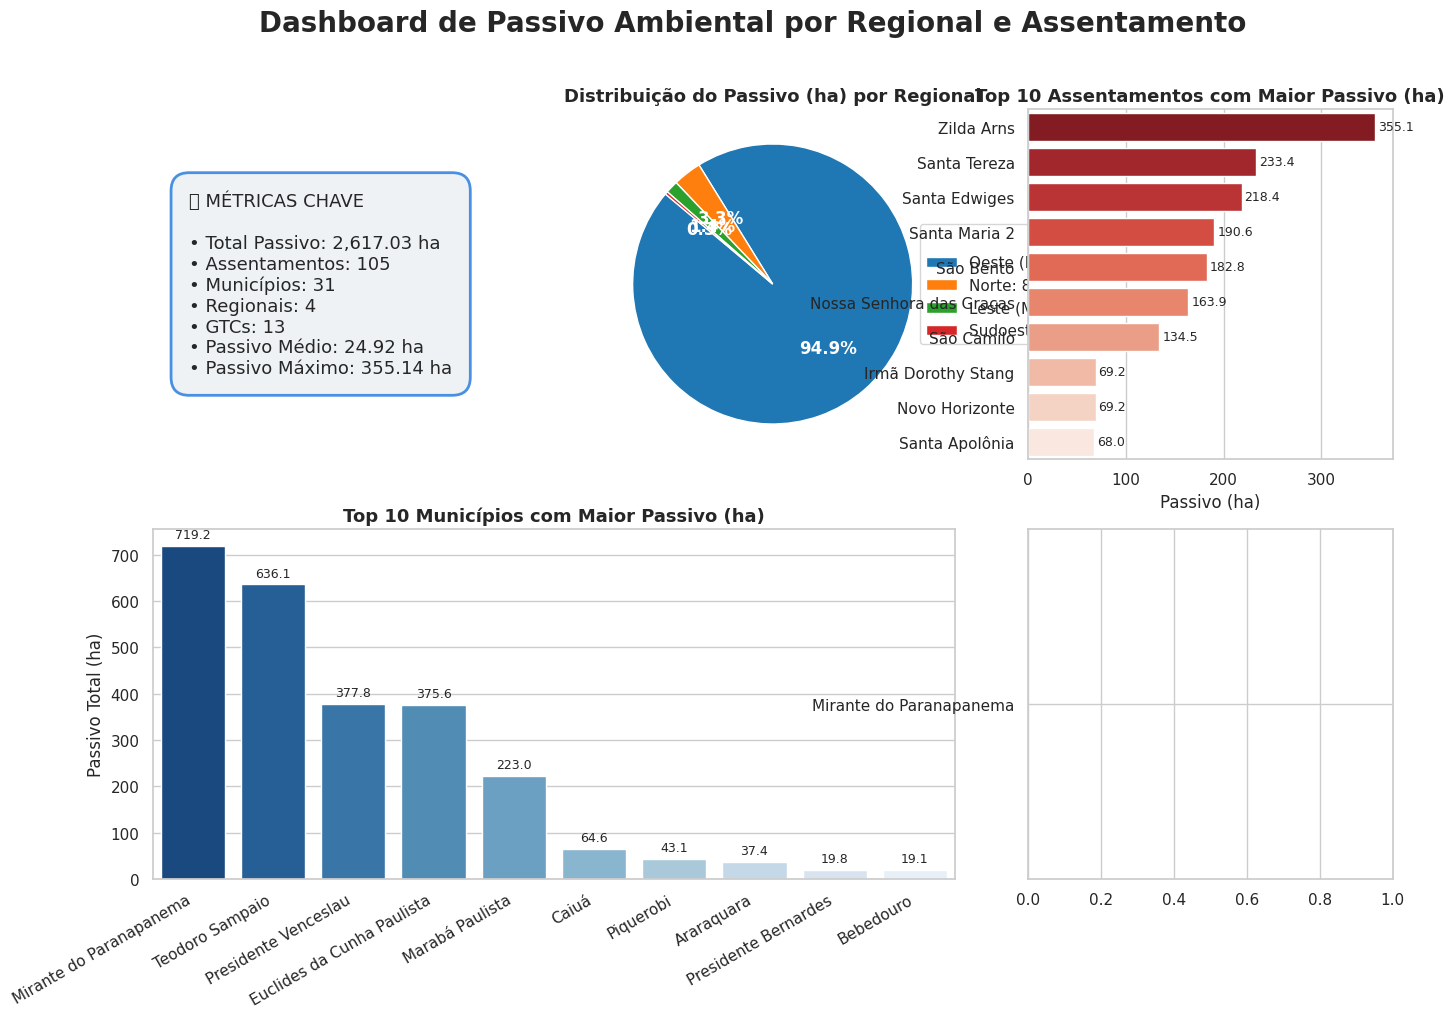

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Create main summary dashboard figure
fig = plt.figure(figsize=(16, 10))

# Title
fig.suptitle('Dashboard de Passivo Ambiental por Regional e Assentamento', fontsize=20, fontweight='bold', y=0.98)

# 1. Total KPI Cards (using inset axes or subplots)
ax1 = plt.subplot2grid((2, 3), (0, 0))
ax1.axis('off')
kpi_text = (
    "📊 MÉTRICAS CHAVE\n\n"
    f"• Total Passivo: {df['Passivo-ha'].sum():,.2f} ha\n"
    f"• Assentamentos: {df['assentamen'].nunique()}\n"
    f"• Municípios: {df['municipio'].nunique()}\n"
    f"• Regionais: {df['regional'].nunique()}\n"
    f"• GTCs: {df['gtc'].nunique()}\n"
    f"• Passivo Médio: {df['Passivo-ha'].mean():.2f} ha\n"
    f"• Passivo Máximo: {df['Passivo-ha'].max():.2f} ha"
)
ax1.text(0.1, 0.5, kpi_text, fontsize=13, verticalalignment='center', bbox=dict(boxstyle='round,pad=1', facecolor='#eef2f5', edgecolor='#4a90e2', lw=2))

# 2. Passivo por Regional (Pie / Donut chart)
ax2 = plt.subplot2grid((2, 3), (0, 1))
reg_sum = df.groupby('regional')['Passivo-ha'].sum().sort_values(ascending=False)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
wedges, texts, autotexts = ax2.pie(reg_sum, labels=reg_sum.index, autopct='%1.1f%%', startangle=140, colors=colors, textprops=dict(color="w", weight="bold"))
ax2.set_title('Distribuição do Passivo (ha) por Regional', fontsize=13, fontweight='bold')
# Make legend
ax2.legend(wedges, [f"{l}: {v:,.1f} ha" for l, v in zip(reg_sum.index, reg_sum.values)], title="Regional", loc="center left", bbox_to_anchor=(0.9, 0, 0.5, 1))

# 3. Top 10 Assentamentos por Passivo (ha)
ax3 = plt.subplot2grid((2, 3), (0, 2))
top_ass = df.sort_values(by='Passivo-ha', ascending=False).head(10)
sns.barplot(x='Passivo-ha', y='assentamen', data=top_ass, palette='Reds_r', ax=ax3)
ax3.set_title('Top 10 Assentamentos com Maior Passivo (ha)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Passivo (ha)')
ax3.set_ylabel('')
for p in ax3.patches:
    width = p.get_width()
    ax3.annotate(f'{width:.1f}', (width + 3, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=9)

# 4. Top 10 Municípios por Passivo (ha)
ax4 = plt.subplot2grid((2, 3), (1, 0), colspan=2)
top_mun = df.groupby('municipio')['Passivo-ha'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x='municipio', y='Passivo-ha', data=top_mun, palette='Blues_r', ax=ax4)
ax4.set_title('Top 10 Municípios com Maior Passivo (ha)', fontsize=13, fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('Passivo Total (ha)')
plt.xticks(rotation=30, ha='right')
for p in ax4.patches:
    height = p.get_height()
    ax4.annotate(f'{height:.1f}', (p.get_x() + p.get_width() / 2., height + 10), ha='center', va='bottom', fontsize=9)

# 5. Passivo por GTC (Top 8)
ax5 = plt.subplot2grid((2, 3), (1, 2))
top_gtc = df.groupby('gtc')['Passivo-ha'].sum().sort_values(ascending=False).head(8).reset_index()
sns.barplot(x='Passivo-ha', y='gtc', data=top_gtc, palette='Viridis_r', ax=ax5)
ax5.set_title('Top GTCs por Passivo (ha)', fontsize=13, fontweight='bold')
ax5.set_xlabel('Passivo (ha)')
ax5.set_ylabel('')
for p in ax5.patches:
    width = p.get_width()
    ax5.annotate(f'{width:.1f}', (width + 5, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('dashboard_overview.png', dpi=300)
plt.close()
print("Dashboard chart saved as dashboard_overview.png")

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_theme(style="whitegrid")

# Create main summary dashboard figure
fig = plt.figure(figsize=(16, 10))

# Title
fig.suptitle('Dashboard de Passivo Ambiental por Regional e Assentamento', fontsize=18, fontweight='bold', y=0.98)

# 1. Total KPI Cards
ax1 = plt.subplot2grid((2, 3), (0, 0))
ax1.axis('off')
kpi_text = (
    "📊 MÉTRICAS CHAVE\n\n"
    f"• Total Passivo: {df['Passivo-ha'].sum():,.2f} ha\n"
    f"• Assentamentos: {df['assentamen'].nunique()}\n"
    f"• Municípios: {df['municipio'].nunique()}\n"
    f"• Regionais: {df['regional'].nunique()}\n"
    f"• GTCs: {df['gtc'].nunique()}\n\n"
    f"• Passivo Médio: {df['Passivo-ha'].mean():.2f} ha\n"
    f"• Passivo Máximo: {df['Passivo-ha'].max():.2f} ha"
)
ax1.text(0.1, 0.5, kpi_text, fontsize=12, verticalalignment='center', bbox=dict(boxstyle='round,pad=1', facecolor='#f0f4f8', edgecolor='#3182bd', lw=2))

# 2. Passivo por Regional (Pie / Donut chart)
ax2 = plt.subplot2grid((2, 3), (0, 1))
reg_sum = df.groupby('regional')['Passivo-ha'].sum().sort_values(ascending=False)
colors = ['#2b5c8f', '#e6550d', '#31a354', '#756bb1']
wedges, texts, autotexts = ax2.pie(reg_sum, labels=None, autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.75)
ax2.set_title('Distribuição do Passivo por Regional', fontsize=12, fontweight='bold')
ax2.legend(wedges, [f"{l}: {v:,.1f} ha" for l, v in zip(reg_sum.index, reg_sum.values)], title="Regional", loc="center left", bbox_to_anchor=(0.85, 0.5))

# 3. Top 10 Assentamentos por Passivo (ha)
ax3 = plt.subplot2grid((2, 3), (0, 2))
top_ass = df.sort_values(by='Passivo-ha', ascending=False).head(10)
sns.barplot(x='Passivo-ha', y='assentamen', data=top_ass, palette='Reds', ax=ax3)
ax3.set_title('Top 10 Assentamentos (Passivo em ha)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Passivo (ha)')
ax3.set_ylabel('')
for p in ax3.patches:
    width = p.get_width()
    ax3.annotate(f'{width:.1f}', (width + 3, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=8)

# 4. Top 10 Municípios por Passivo (ha)
ax4 = plt.subplot2grid((2, 3), (1, 0), colspan=2)
top_mun = df.groupby('municipio')['Passivo-ha'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(x='municipio', y='Passivo-ha', data=top_mun, palette='Blues', ax=ax4)
ax4.set_title('Top 10 Municípios com Maior Passivo (ha)', fontsize=12, fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('Passivo Total (ha)')
plt.xticks(rotation=25, ha='right')
for p in ax4.patches:
    height = p.get_height()
    ax4.annotate(f'{height:.1f}', (p.get_x() + p.get_width() / 2., height + 8), ha='center', va='bottom', fontsize=8)

# 5. Passivo por GTC (Top 8)
ax5 = plt.subplot2grid((2, 3), (1, 2))
top_gtc = df.groupby('gtc')['Passivo-ha'].sum().sort_values(ascending=False).head(8).reset_index()
sns.barplot(x='Passivo-ha', y='gtc', data=top_gtc, palette='Greens', ax=ax5)
ax5.set_title('Top GTCs por Passivo (ha)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Passivo (ha)')
ax5.set_ylabel('')
for p in ax5.patches:
    width = p.get_width()
    ax5.annotate(f'{width:.1f}', (width + 5, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('dashboard_overview.png', dpi=300)
plt.close()
print("Saved dashboard_overview.png successfully.")

/tmp/ipykernel_1562/621055515.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Passivo-ha', y='assentamen', data=top_ass, palette='Reds', ax=ax3)
/tmp/ipykernel_1562/621055515.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='municipio', y='Passivo-ha', data=top_mun, palette='Blues', ax=ax4)
/tmp/ipykernel_1562/621055515.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Passivo-ha', y='gtc', data=top_gtc, palette='Greens', ax=ax5)
/tmp/ipykernel_1562/621055515.py:71: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from f

Saved dashboard_overview.png successfully.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig = plt.figure(figsize=(18, 11), facecolor='#f8f9fa')

# Title Header
plt.suptitle('DASHBOARD EXECUTIVO - PASSIVO AMBIENTAL DISSOLVIDO', fontsize=22, fontweight='bold', color='#1a252f', y=0.96)

# 1. Metric Cards (KPI Box)
ax1 = plt.subplot2grid((2, 3), (0, 0))
ax1.axis('off')
kpi_card = ax1.inset_axes([0.05, 0.05, 0.9, 0.9])
kpi_card.axis('off')
kpi_card.patch.set_facecolor('#ffffff')
kpi_card.patch.set_edgecolor('#cbd5e1')
kpi_card.patch.set_linewidth(1.5)

kpi_text = (
    "  RESUMO GERAL\n\n"
    f"  • Passivo Total:  {df['Passivo-ha'].sum():,.2f} ha\n\n"
    f"  • Assentamentos:  {df['assentamen'].nunique()}\n\n"
    f"  • Municípios:     {df['municipio'].nunique()}\n\n"
    f"  • Regionais:      {df['regional'].nunique()}\n\n"
    f"  • GTCs:           {df['gtc'].nunique()}\n\n"
    f"  • Média/Assent.:  {df['Passivo-ha'].mean():.2f} ha\n\n"
    f"  • Máximo:         {df['Passivo-ha'].max():.2f} ha"
)
kpi_card.text(0.08, 0.5, kpi_text, fontsize=12, verticalalignment='center', fontfamily='monospace', fontweight='bold', color='#334155',
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f1f5f9', edgecolor='#94a3b8', lw=1.5))

# 2. Passivo por Regional (Horizontal Bar Chart)
ax2 = plt.subplot2grid((2, 3), (0, 1))
reg_df = df.groupby('regional')['Passivo-ha'].sum().reset_index().sort_values(by='Passivo-ha', ascending=True)
bars = ax2.barh(reg_df['regional'], reg_df['Passivo-ha'], color=['#38bdf8', '#4ade80', '#fb923c', '#0284c7'], height=0.55)
ax2.set_title('Passivo Total por Regional (ha)', fontsize=13, fontweight='bold', color='#1e293b', pad=12)
ax2.set_xlabel('Hectares (ha)', fontsize=10, color='#475569')
ax2.grid(True, linestyle='--', alpha=0.5)
for bar in bars:
    w = bar.get_width()
    pct = (w / df['Passivo-ha'].sum()) * 100
    ax2.annotate(f' {w:,.1f} ha ({pct:.1f}%)', (w, bar.get_y() + bar.get_height()/2), ha='left', va='center', fontsize=9, fontweight='bold', color='#1e293b')
ax2.set_xlim(0, max(reg_df['Passivo-ha']) * 1.3)

# 3. Top 8 Assentamentos por Passivo (ha)
ax3 = plt.subplot2grid((2, 3), (0, 2))
top_ass = df.sort_values(by='Passivo-ha', ascending=True).tail(8)
bars_ass = ax3.barh(top_ass['assentamen'], top_ass['Passivo-ha'], color='#ef4444', height=0.55)
ax3.set_title('Top 8 Assentamentos (Maior Passivo ha)', fontsize=13, fontweight='bold', color='#1e293b', pad=12)
ax3.set_xlabel('Hectares (ha)', fontsize=10, color='#475569')
ax3.grid(True, linestyle='--', alpha=0.5)
for bar in bars_ass:
    w = bar.get_width()
    ax3.annotate(f' {w:,.1f} ha', (w, bar.get_y() + bar.get_height()/2), ha='left', va='center', fontsize=9, fontweight='bold', color='#7f1d1d')
ax3.set_xlim(0, max(top_ass['Passivo-ha']) * 1.25)

# 4. Top 8 Municípios por Passivo (ha)
ax4 = plt.subplot2grid((2, 3), (1, 0), colspan=2)
top_mun = df.groupby('municipio')['Passivo-ha'].sum().sort_values(ascending=False).head(8).reset_index()
bars_mun = ax4.bar(top_mun['municipio'], top_mun['Passivo-ha'], color='#2563eb', width=0.5)
ax4.set_title('Top 8 Municípios com Maior Passivo Acumulado (ha)', fontsize=13, fontweight='bold', color='#1e293b', pad=12)
ax4.set_ylabel('Hectares (ha)', fontsize=10, color='#475569')
ax4.grid(True, linestyle='--', alpha=0.5)
plt.setp(ax4.get_xticklabels(), rotation=20, ha='right', fontsize=10, fontweight='medium')
for bar in bars_mun:
    h = bar.get_height()
    ax4.annotate(f'{h:,.1f} ha', (bar.get_x() + bar.get_width()/2, h + 15), ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1e3a8a')
ax4.set_ylim(0, max(top_mun['Passivo-ha']) * 1.15)

# 5. Top 6 GTCs por Passivo (ha)
ax5 = plt.subplot2grid((2, 3), (1, 2))
top_gtc = df.groupby('gtc')['Passivo-ha'].sum().sort_values(ascending=True).tail(6).reset_index()
bars_gtc = ax5.barh(top_gtc['gtc'], top_gtc['Passivo-ha'], color='#059669', height=0.55)
ax5.set_title('Top 6 Grupos Técnicos de Campo (GTC)', fontsize=13, fontweight='bold', color='#1e293b', pad=12)
ax5.set_xlabel('Hectares (ha)', fontsize=10, color='#475569')
ax5.grid(True, linestyle='--', alpha=0.5)
for bar in bars_gtc:
    w = bar.get_width()
    ax5.annotate(f' {w:,.1f} ha', (w, bar.get_y() + bar.get_height()/2), ha='left', va='center', fontsize=9, fontweight='bold', color='#064e3b')
ax5.set_xlim(0, max(top_gtc['Passivo-ha']) * 1.25)

plt.subplots_adjust(wspace=0.35, hspace=0.35, top=0.90, bottom=0.08, left=0.06, right=0.96)
plt.savefig('dashboard_executivo.png', dpi=300, facecolor='#f8f9fa')
plt.close()
print("Saved dashboard_executivo.png successfully.")

Saved dashboard_executivo.png successfully.
